# 07 Text-to-Image：文生图原理——Stable Diffusion 拆解

> 前置：`03-attention-mechanism`（交叉注意力）、`05-vae`、`06-diffusion-models`。
> 目标：把 Stable Diffusion（SD）这条现代文生图管线拆成四块——**VAE / U-Net / 文本编码器 / 调度器**——并动手实现交叉注意力与无分类器引导。

## SD 管线总览

```
文本 "a red fox" ──→ 文本编码器(CLIP) ──→ 文本嵌入 (T, d)
                                              │
随机噪声 z_T (4×64×64) ──→ U-Net(带交叉注意力) ──→ … 迭代去噪 … ──→ z_0 (4×64×64)
                                              │
                                       VAE 解码器 ──→ 图像 (3×512×512)
```

关键设计：**不在像素空间扩散，而在 VAE 潜空间（8× 压缩）扩散**——计算量降到 1/64，这是 SD 能在消费级 GPU 上跑的原因。

## 四个组件

| 组件 | 作用 | 训练方式 |
|---|---|---|
| VAE（VQ-VAE） | 像素 ↔ 潜空间双向压缩 | 自监督重建 |
| 文本编码器 | 文本 → 条件向量 | CLIP 对比学习（固定） |
| U-Net | 潜空间去噪（含交叉注意力注入文本） | 扩散损失（预测噪声） |
| 调度器 | β 调度 + 采样步数 | 无参数（DDIM 等） |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
# 交叉注意力：图像特征 query 文本特征 key/value
class CrossAttention(nn.Module):
    def __init__(self, d_img=32, d_text=32, n_heads=4):
        super().__init__()
        assert d_img % n_heads == 0
        self.dk = d_img // n_heads
        self.n_heads = n_heads
        self.Wq = nn.Linear(d_img, d_img)
        self.Wk = nn.Linear(d_text, d_img)
        self.Wv = nn.Linear(d_text, d_img)
        self.Wo = nn.Linear(d_img, d_img)
    def forward(self, img_feat, text_feat):
        B, H, W, d = img_feat.shape
        q = self.Wq(img_feat).view(B, H * W, self.n_heads, self.dk).transpose(1, 2)   # (B,h,HW,dk)
        k = self.Wk(text_feat).view(B, -1, self.n_heads, self.dk).transpose(1, 2)     # (B,h,T,dk)
        v = self.Wv(text_feat).view(B, -1, self.n_heads, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)   # (B,h,HW,T)
        attn = torch.softmax(scores, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, H, W, d)
        return self.Wo(out), attn

ca = CrossAttention()
img_feat = torch.randn(2, 8, 8, 32)     # 模拟潜空间特征 (B, H, W, d)
text_feat = torch.randn(2, 5, 32)       # 模拟 5 个 token 的文本嵌入
out, attn = ca(img_feat, text_feat)
print("输出:", tuple(out.shape), " 注意力图:", tuple(attn.shape), "(B, heads, 图像位置, 文本位置)")
print("每行（每个图像位置）对文本 token 的注意力权重和 =", attn[0, 0].sum(-1).mean().item())

输出: (2, 8, 8, 32)  注意力图: (2, 4, 64, 5) (B, heads, 图像位置, 文本位置)
每行（每个图像位置）对文本 token 的注意力权重和 = 1.0


## 注意力图可视化

每个图像位置都"查看"文本 token 并加权聚合信息——这就是"文本条件"注入图像的机制。

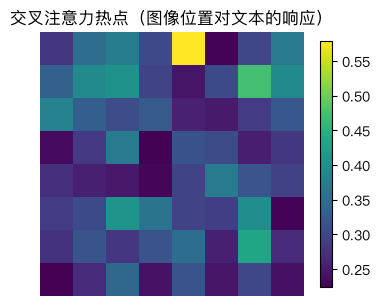

In [3]:
with torch.no_grad():
    img_feat2 = torch.randn(1, 8, 8, 32)
    text_feat2 = torch.randn(1, 5, 32)
    _, attn2 = ca(img_feat2, text_feat2)
    # 取第 0 个头，按文本位置聚合出每像素的"关注热点"
    heat = attn2[0, 0].max(-1).values.reshape(8, 8).numpy()

plt.figure(figsize=(3.6, 3.4))
plt.imshow(heat, cmap="viridis"); plt.colorbar(shrink=0.8)
plt.title("交叉注意力热点（图像位置对文本的响应）")
plt.axis("off"); plt.tight_layout(); plt.show()

## 无分类器引导（CFG）：让条件更强

扩散模型可以训两个版本：有条件的 $\varepsilon_\theta(x_t, t, c)$ 与无条件的 $\varepsilon_\theta(x_t, t, \varnothing)$（训练时按概率把文本置空）。采样时**外推**：

$$\tilde{\varepsilon} = \varepsilon_\theta(x_t, t, \varnothing) + w\,\big(\varepsilon_\theta(x_t, t, c) - \varepsilon_\theta(x_t, t, \varnothing)\big)$$

$w=1$ 是普通条件生成；$w>1$（典型 7.5）让模型**更激进地按文本去噪**——更贴合提示词，但过度会伪影。

In [4]:
# CFG 引导强度演示：三种 w 的语义
for w, desc in [(0.0, "纯无条件生成（只靠模型先验）"),
                (1.0, "普通条件生成"),
                (7.5, "典型强引导（SD 默认）"),
                (15.0, "过强引导（伪影风险）")]:
    print(f"w = {w:>5.1f}   ε̃ = ε_uncond + {w:.1f}×(ε_cond − ε_uncond)   {desc}")

w =   0.0   ε̃ = ε_uncond + 0.0×(ε_cond − ε_uncond)   纯无条件生成（只靠模型先验）
w =   1.0   ε̃ = ε_uncond + 1.0×(ε_cond − ε_uncond)   普通条件生成
w =   7.5   ε̃ = ε_uncond + 7.5×(ε_cond − ε_uncond)   典型强引导（SD 默认）
w =  15.0   ε̃ = ε_uncond + 15.0×(ε_cond − ε_uncond)   过强引导（伪影风险）


## 现代演进（2023-2026）

| 模型 | 关键改动 |
|---|---|
| SD 1.5/2.x | U-Net + CLIP + VAE，开源标杆 |
| SDXL | 双文本编码器 + 更大 U-Net，构图大幅提升 |
| SD 3 / Flux | 换用整流流（rectified flow）训练，改 DiT 骨干 |
| Sora / 视频扩散 | 把图像扩散推广到时空（3D patch） |
| LoRA/ControlNet | 低成本定制与结构控制（姿态/深度/边缘） |

**本课要点**：文生图 = 条件扩散（交叉注意力注入文本）+ 潜空间压缩（VAE）+ 引导（CFG）。这三块拼在一起，就是 2024 年之前绝大多数产品的内核。

## 课后练习

1. 把交叉注意力的头数从 4 改成 1，观察注意力图的变化——多头如何分解不同语义？
2. 手动实现 CFG 公式：给定 ε_cond、ε_uncond 两个张量，分别用 w=1 和 w=7.5 计算 ε̃，验证"外推"是线性组合。
3. 思考：为什么 SD 要在潜空间扩散而不是像素空间？列出至少两个理由（计算量、感知压缩）。